# ER 图随机基准：cd_A_noepoch / greedy_cd_noepoch / NOTEARS / FGES / GOLEM-EV / Gumbel-Softmax / XGES

随机生成 ER 图，对比以下算法：

- **cd_A_noepoch** (λ=0.0 / 0.1 / 0.2)：坐标下降（非 epoch），via `coordinate_descent.coordinate0`
- **greedy_cd_noepoch** (λ=0.0 / 0.1 / 0.2)：贪婪坐标下降（非 epoch），via `coordinate_descent.cd_greedy_A`
- **NOTEARS**：连续松弛 + 增广拉格朗日，via `gcastle`
- **FGES**：Fast Greedy Equivalence Search，via `pytetrad`（需 JDK 21+）
- **GOLEM-EV**：等方差假设 GOLEM，via `golemMain/src/golem.py`
- **Gumbel-Softmax**：Binary-Concrete 门控 + SGD + 温度退火，via `nodag.nodag_gumbel_softmax.train_gumbel_sgd_dag`
- **XGES**：Extremely Greedy Equivalence Search（ANazaret/XGES），via `pip install xges`

每个算法在独立 cell 中执行；结果在最后汇总比较。

In [28]:
# 1) 环境与导入
import os
import sys
import time
import logging
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ── 仓库根目录 ────────────────────────────────────────────────────────────────
repo_root = os.path.abspath(os.path.join(os.getcwd(), '..', '..', '..'))
if repo_root not in sys.path:
    sys.path.insert(0, repo_root)
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'
if not os.environ.get('JAVA_HOME'):
    _jdk_candidate = r'C:\Program Files\Microsoft\jdk-21.0.10.7-hotspot'
    if os.path.isdir(_jdk_candidate):
        os.environ['JAVA_HOME'] = _jdk_candidate


print('Python   :', sys.version.split()[0])
print('Repo root:', repo_root)

# ── 核心依赖 ──────────────────────────────────────────────────────────────────
from MEC import is_in_markov_equiv_class, get_skeleton, find_v_structures
from synthetic_dataset import SyntheticDataset

# ── cd_A (non-epoch) ──────────────────────────────────────────────────────────
from coordinate_descent.coordinate0 import dag_coordinate_descent_l0 as cd_A_noepoch

# ── cd_A_weakfaith (one-edge faithfulness screening) ─────────────────────
from coordinate_descent.cd_A_weakfaith import dag_coordinate_descent_l0_weakfaith as cd_A_weakfaith_fit

# ── Greedy-CD (non-epoch) ─────────────────────────────────────────────────────
try:
    from coordinate_descent.cd_greedy_A import dag_greedy_A as greedy_cd_noepoch_fit
    HAS_GREEDY_CD = True
    print('Greedy-CD : OK')
except Exception as _e:
    HAS_GREEDY_CD = False
    print('Greedy-CD unavailable:', _e)

# ── NOTEARS (gcastle) ─────────────────────────────────────────────────────────
NOTEARS_IMPORT_ERROR = None
try:
    logging.disable(logging.INFO)
    from castle.algorithms import Notears as _Notears
    logging.disable(logging.NOTSET)
    HAS_NOTEARS = True
    print('NOTEARS   : OK')
except Exception as _e:
    logging.disable(logging.NOTSET)
    HAS_NOTEARS = False
    NOTEARS_IMPORT_ERROR = _e
    print('NOTEARS unavailable:', _e)

# ── FGES (pytetrad, requires JDK 21+) ────────────────────────────────────────
FGES_IMPORT_ERROR = None
try:
    import fges_compat as _ts
    _probe = pd.DataFrame(np.eye(2), columns=['x0', 'x1'])
    _s = _ts.TetradSearch(_probe)
    _s.set_verbose(False)
    _s.use_sem_bic()
    _s.run_fges()
    del _probe, _s
    HAS_FGES = True
    print('FGES      : OK')
except Exception as _e:
    HAS_FGES = False
    FGES_IMPORT_ERROR = _e
    print('FGES unavailable:', _e)

# ── GOLEM ─────────────────────────────────────────────────────────────────────
GOLEM_IMPORT_ERROR = None
try:
    _golem_src = os.path.join(repo_root, 'golemMain', 'src')
    if _golem_src not in sys.path:
        sys.path.append(_golem_src)
    from golem import golem as golem_fit
    HAS_GOLEM = True
    print('GOLEM     : OK')
except Exception as _e:
    HAS_GOLEM = False
    GOLEM_IMPORT_ERROR = _e
    print('GOLEM unavailable:', _e)

# ── Gumbel-Softmax (项目内 nodag) ─────────────────────────────────────────────
GUMBEL_IMPORT_ERROR = None
try:
    from nodag.nodag_gumbel_softmax import train_gumbel_sgd_dag as gumbel_fit
    HAS_GUMBEL = True
    print('Gumbel-SM : OK')
except Exception as _e:
    HAS_GUMBEL = False
    GUMBEL_IMPORT_ERROR = _e
    print('Gumbel-SM unavailable:', _e)

# ── XGES (pip install xges) ──────────────────────────────────────────────────
XGES_IMPORT_ERROR = None
try:
    import xges as _xges
    HAS_XGES = True
    print(f'XGES      : OK (v{_xges.__version__})')
except Exception as _e:
    HAS_XGES = False
    XGES_IMPORT_ERROR = _e
    print('XGES unavailable:', _e)

# ── CPDAG-SHD backend (optional) ─────────────────────────────────────────────
try:
    _tb = os.path.join(repo_root, 'toolbox')
    if _tb not in sys.path:
        sys.path.append(_tb)
    from cdt.metrics import SHD_CPDAG as _SHD_CPDAG
    HAS_CPDAG_SHD = True
except Exception as _e:
    _SHD_CPDAG = None
    HAS_CPDAG_SHD = False
    print('CPDAG-SHD backend unavailable (fallback):', _e)


Python   : 3.10.11
Repo root: c:\Users\super\DAG
Greedy-CD : OK
NOTEARS   : OK
FGES      : OK
GOLEM     : OK
Gumbel-SM : OK
XGES      : OK (v0.1.6)
CPDAG-SHD backend unavailable (fallback): No module named 'GPUtil'


In [25]:
# ── 从 notebook 已保存的 cell 输出中恢复上次实验结果 ──────────────────────────
# 关机后 kernel 状态丢失，但 cell 输出仍保留在 .ipynb JSON 中。
# 本 cell 解析 stdout 中形如
#   [algorithm] d=40 n=20000 trial=1  mec=0  shd=54  cpdag_shd=102  rt=14.985s
# 的行，重建 _ALL_ROWS，使后续分析 cell 可以直接运行。

import json, re, os

_nb_path = os.path.abspath('test_er_benchmark_20260330.ipynb')
with open(_nb_path, encoding='utf-8') as _f:
    _nb = json.load(_f)

_pattern = re.compile(
    r'\[(?P<alg>[^\]]+)\]\s+'
    r'd=(?P<d>\d+)\s+'
    r'n=(?P<n>\d+)\s+'
    r'trial=(?P<trial>\d+)\s+'
    r'mec=(?P<mec>\d+)\s+'
    r'shd=(?P<shd>[\d.]+)\s+'
    r'cpdag_shd=(?P<cpdag_shd>[\d.]+)\s+'
    r'rt=(?P<rt>[\d.]+)s'
)

_ALL_ROWS = []
_SKIP_LOGS = []

for _cell in _nb['cells']:
    if _cell['cell_type'] != 'code':
        continue
    for _out in _cell.get('outputs', []):
        if _out.get('name') != 'stdout':
            continue
        _text = ''.join(_out.get('text', []))
        for _m in _pattern.finditer(_text):
            _ALL_ROWS.append({
                'd':           int(_m.group('d')),
                'n_samples':   int(_m.group('n')),
                'trial_id':    int(_m.group('trial')),
                'seed':        -1,           # stdout 中未打印 seed
                'algorithm':   _m.group('alg'),
                'mec_match':   int(_m.group('mec')),
                'shd':         float(_m.group('shd')),
                'cpdag_shd':   float(_m.group('cpdag_shd')),
                'n_edges_true': -1,          # stdout 中未打印
                'n_edges_est':  -1,
                'runtime_sec': float(_m.group('rt')),
            })

df_all_trials = pd.DataFrame(_ALL_ROWS)

print(f'从 notebook 已保存输出中恢复了 {len(_ALL_ROWS)} 条记录。')
if len(df_all_trials) > 0:
    print(f"算法: {df_all_trials['algorithm'].unique().tolist()}")
    print(f"d:    {sorted(df_all_trials['d'].unique())}")
    print(f"n:    {sorted(df_all_trials['n_samples'].unique())}")
    print(df_all_trials['algorithm'].value_counts())


从 notebook 已保存输出中恢复了 275 条记录。
算法: ['cd_A_noepoch_l0_2.0', 'cd_A_noepoch_l0_5.0', 'cd_A_noepoch_l0_10.0', 'notears', 'fges', 'golem_ev', 'gumbel_softmax', 'xges']
d:    [30, 40, 50]
n:    [20000]
algorithm
cd_A_noepoch_l0_2.0     60
cd_A_noepoch_l0_5.0     60
cd_A_noepoch_l0_10.0    60
notears                 34
fges                    20
gumbel_softmax          20
xges                    20
golem_ev                 1
Name: count, dtype: int64


In [23]:
# 2) 辅助函数

def weight_to_binary_adj(W: np.ndarray, threshold: float = 0.05) -> np.ndarray:
    G = (np.abs(W) > threshold).astype(int)
    np.fill_diagonal(G, 0)
    return G


def cpdag_shd_score(G_true: np.ndarray, G_est: np.ndarray) -> float:
    if HAS_CPDAG_SHD:
        try:
            return float(_SHD_CPDAG(G_true.astype(int), G_est.astype(int)))
        except Exception:
            pass
    skel_true = get_skeleton(G_true)
    skel_est  = get_skeleton(G_est)
    skel_diff = int(np.sum(np.abs(skel_true - skel_est)) // 2)
    v_diff    = len(find_v_structures(G_true).symmetric_difference(find_v_structures(G_est)))
    return float(skel_diff + v_diff)


def shd_score(G_true: np.ndarray, G_est: np.ndarray) -> float:
    G_true = np.asarray(G_true, dtype=int)
    G_est  = np.asarray(G_est,  dtype=int)
    d, dist = G_true.shape[0], 0
    for i in range(d):
        for j in range(i + 1, d):
            if G_true[i, j] != G_est[i, j] or G_true[j, i] != G_est[j, i]:
                dist += 1
    return float(dist)


def fges_matrix_to_adj(df_result) -> np.ndarray:
    """pytetrad get_graph_to_matrix() -> 0/1 adjacency (ARROW=2, TAIL=3)."""
    mat = df_result.values
    d   = mat.shape[0]
    G   = np.zeros((d, d), dtype=int)
    for i in range(d):
        for j in range(i + 1, d):
            a, b = int(mat[i, j]), int(mat[j, i])
            if   a == 2 and b == 3: G[i, j] = 1
            elif a == 3 and b == 2: G[j, i] = 1
            elif a == 3 and b == 3: G[i, j] = G[j, i] = 1
            elif a != 0 or  b != 0: G[i, j] = G[j, i] = 1
    np.fill_diagonal(G, 0)
    return G


def _make_row(d, n, trial_id, seed, alg, runtime_sec, G_true, G_est):
    mec  = int(is_in_markov_equiv_class(G_true, G_est))
    shd  = shd_score(G_true, G_est)
    cshd = cpdag_shd_score(G_true, G_est)
    return {
        'd': d, 'n_samples': n, 'trial_id': trial_id, 'seed': seed,
        'algorithm': alg,
        'mec_match': mec,
        'shd': shd,
        'cpdag_shd': cshd,
        'n_edges_true': int(G_true.sum()),
        'n_edges_est':  int(G_est.sum()),
        'runtime_sec': float(runtime_sec),
    }


def summarize(df: pd.DataFrame) -> pd.DataFrame:
    if len(df) == 0:
        return pd.DataFrame()
    return (
        df.groupby(['algorithm', 'd', 'n_samples'], as_index=False)
        .agg(
            mec_match_mean   = ('mec_match',   'mean'),
            shd_mean         = ('shd',         'mean'),
            cpdag_shd_mean   = ('cpdag_shd',   'mean'),
            runtime_sec_mean = ('runtime_sec', 'mean'),
            trials           = ('trial_id',    'count'),
        )
    )


# 各算法 cell 将结果追加到这个全局列表
_ALL_ROWS: list = []
_SKIP_LOGS: list = []

print('辅助函数已定义。')


辅助函数已定义。


In [ ]:
# 3) 实验配置
CFG = {
    # ── ER 图参数 ────────────────────────────────────────────────────────────
    'trials':       5,            # 每组 (d, n) 重复次数
    'seed':         42,
    'd_list':       [30, 40, 50], # 节点数
    'n_list':       [20000], # 样本量
    'degree':       4.0,          # ER 图期望度
    'noise_type':   'gaussian_nv',
    'noise_ratio':  1.0,          # Noise scale multiplier; 1.0 preserves SyntheticDataset default behavior
    'b_scale':      1.0,

    # ── 通用 ──────────────────────────────────────────────────────────────
    'threshold':    0.05,

    # ── cd_A_noepoch / greedy_cd_noepoch 参数 ──────────────────────────────
    'T_noepoch':      100000,           # 坐标下降步数上限
    'lambda_l0_list': [2.0, 5.0, 10.0],

    # ── cd_A_noepoch / greedy_cd_noepoch 的早停（step 版） ─────────────────
    'cd_early_stop':    True,
    'cd_tol':           1e-4,           # 相对改善阈值
    'cd_patience':      10,             # 连续多少次 check 未改善才停
    'cd_check_every':   None,           # None → d*(d+1)//2
    'cd_min_steps':     None,           # None → check_every * 10

    # ── NOTEARS ───────────────────────────────────────────────────────────
    'notears_lambda1':    0.1,
    'notears_loss_type':  'l2',
    'notears_threshold':  0.3,

    # ── FGES ──────────────────────────────────────────────────────────────
    'fges_penalty_discount': 1.0,

    # ── GOLEM ─────────────────────────────────────────────────────────────
    'golem_num_iter':      100000,
    'golem_learning_rate': 1e-3,
    'golem_lambda1_ev':    2e-2,
    'golem_lambda2':       5.0,

    # ── Gumbel-Softmax ────────────────────────────────────────────────────
    'gumbel_lam':          0.5,          # Binary-concrete gate 的 L1-like 稀疏惩罚
    'gumbel_delta':        1e-6,
    'gumbel_max_steps':    100000,
    'gumbel_lr':           1e-2,
    'gumbel_tau_start':    1.0,
    'gumbel_tau_end':      0.2,

    # ── XGES ──────────────────────────────────────────────────────────────
    'xges_alpha':          2.0,          # BIC 惩罚系数；越大越稀疏
    'xges_use_fast_numba': False,        # 当前 numba 路径有类型冲突，先用纯 Python

    # ── cd_A_weakfaith ────────────────────────────────────────
    'weakfaith_tau':             0.05,
    'weakfaith_lambda_l0_list':  [0.01,0.2],

    # ── 输出 ──────────────────────────────────────────────────────────────
    'out_dir': os.path.join(repo_root, 'experiments', 'results'),
    'tag':     'er_benchmark_20260330',
}
os.makedirs(CFG['out_dir'], exist_ok=True)

_wf_bases = [
    'wf_corr_tau0.05_preserve',  
    'wf_pcorr_tau0.05_preserve', 'wf_pcorr_tau0.05_pool',
]
ALGORITHM_ORDER = [
    'cd_A_noepoch_l0_10.0',
    # notears',
    'fges',
    'gumbel_softmax',
    'xges',
    'wf_corr_tau0.05_preserve_l0_0.2',
    'wf_pcorr_tau0.05_preserve_l0_0.2',
    'wf_pcorr_tau0.05_pool_l0_0.2'
]

# ALGORITHM_ORDER = [
#     'cd_A_noepoch_l0_0.0',      'cd_A_noepoch_l0_0.1',      'cd_A_noepoch_l0_0.2',
#     'greedy_cd_noepoch_l0_0.0', 'greedy_cd_noepoch_l0_0.1', 'greedy_cd_noepoch_l0_0.2',
#     'notears',
#     'fges',
#     'golem_ev',
#     'gumbel_softmax',
#     'xges',
# ]

print('配置完成。')
print(f"  d_list   : {CFG['d_list']}")
print(f"  n_list   : {CFG['n_list']}")
print(f"  trials   : {CFG['trials']}")
print(f"  noise    : {CFG['noise_type']}  ratio={CFG['noise_ratio']}")
print(f"  早停     : cd_early_stop={CFG['cd_early_stop']} tol={CFG['cd_tol']} "
      f"patience={CFG['cd_patience']} check_every={CFG['cd_check_every']} "
      f"min_steps={CFG['cd_min_steps']}")
print(f"  算法列表 ({len(ALGORITHM_ORDER)} 个):")
for _a in ALGORITHM_ORDER:
    print(f'    {_a}')


In [ ]:
# 4) 通用 ER 图 trial 生成器
# 各算法 cell 调用 _iter_trials(CFG) 来统一遍历 (d, n, trial) 三元组

def _iter_trials(cfg: dict):
    """生成器：依次产出 (d, n, trial_id, seed, X, S, G_true)。"""
    rng = np.random.default_rng(cfg['seed'])
    for d in cfg['d_list']:
        for n in cfg['n_list']:
            seeds = rng.integers(0, 10**9, size=cfg['trials'])
            for trial_idx, seed in enumerate(seeds, start=1):
                dataset = SyntheticDataset(
                    n=n, d=d,
                    graph_type='ER',
                    degree=cfg['degree'],
                    noise_type=cfg['noise_type'],
                    noise_ratio=cfg.get('noise_ratio', 1.0),
                    B_scale=cfg['b_scale'],
                    seed=int(seed),
                )
                X      = dataset.X
                S      = X.T @ X / X.shape[0]
                G_true = weight_to_binary_adj(dataset.B, threshold=0.0)
                yield d, n, trial_idx, int(seed), X, S, G_true


print('ER trial 生成器已定义。')


In [5]:
# 5) cd_A_noepoch  (lambda = 0.0 / 0.1 / 0.2)
# ──────────────────────────────────────────────────────────────────────────────

_rows_cd_A_noepoch = []

for _d, _n, _tid, _seed, _X, _S, _G_true in _iter_trials(CFG):
    for _lam in CFG['lambda_l0_list']:
        _alg = f'cd_A_noepoch_l0_{_lam:.1f}'
        try:
            _t0 = time.perf_counter()
            _, _G_est, _ = cd_A_noepoch(
                S=_S, T=CFG['T_noepoch'], seed=_seed,
                threshold=CFG['threshold'], lambda_l0=_lam,
                early_stop=CFG['cd_early_stop'],
                tol=CFG['cd_tol'],
                patience=CFG['cd_patience'],
                check_every=CFG['cd_check_every'],
                min_steps=CFG['cd_min_steps'],
            )
            _rt  = time.perf_counter() - _t0
            _row = _make_row(_d, _n, _tid, _seed, _alg, _rt, _G_true, _G_est)
        except Exception as _e:
            _SKIP_LOGS.append({'algorithm': _alg, 'd': _d, 'n': _n,
                               'trial_id': _tid, 'reason': str(_e)})
            continue
        _rows_cd_A_noepoch.append(_row)
        _ALL_ROWS.append(_row)
        print(f'[{_alg}] d={_d} n={_n} trial={_tid}  '
              f'mec={_row["mec_match"]}  shd={_row["shd"]:.0f}  '
              f'cpdag_shd={_row["cpdag_shd"]:.0f}  rt={_rt:.3f}s')

df_trials_cd_A_noepoch  = pd.DataFrame(_rows_cd_A_noepoch)
df_summary_cd_A_noepoch = summarize(df_trials_cd_A_noepoch)
print('\ncd_A_noepoch summary:')
display(df_summary_cd_A_noepoch)


[cd_A_noepoch_l0_2.0] d=30 n=20000 trial=1  mec=0  shd=54  cpdag_shd=102  rt=14.985s
[cd_A_noepoch_l0_5.0] d=30 n=20000 trial=1  mec=0  shd=52  cpdag_shd=98  rt=14.825s
[cd_A_noepoch_l0_10.0] d=30 n=20000 trial=1  mec=0  shd=51  cpdag_shd=97  rt=7.012s
[cd_A_noepoch_l0_2.0] d=30 n=20000 trial=2  mec=0  shd=54  cpdag_shd=125  rt=21.904s
[cd_A_noepoch_l0_5.0] d=30 n=20000 trial=2  mec=0  shd=58  cpdag_shd=128  rt=16.894s
[cd_A_noepoch_l0_10.0] d=30 n=20000 trial=2  mec=0  shd=58  cpdag_shd=129  rt=15.898s
[cd_A_noepoch_l0_2.0] d=30 n=20000 trial=3  mec=0  shd=68  cpdag_shd=167  rt=35.038s
[cd_A_noepoch_l0_5.0] d=30 n=20000 trial=3  mec=0  shd=64  cpdag_shd=141  rt=35.358s
[cd_A_noepoch_l0_10.0] d=30 n=20000 trial=3  mec=0  shd=65  cpdag_shd=133  rt=34.394s
[cd_A_noepoch_l0_2.0] d=30 n=20000 trial=4  mec=0  shd=69  cpdag_shd=184  rt=33.371s
[cd_A_noepoch_l0_5.0] d=30 n=20000 trial=4  mec=0  shd=67  cpdag_shd=150  rt=16.845s
[cd_A_noepoch_l0_10.0] d=30 n=20000 trial=4  mec=0  shd=68  cpdag

,algorithm,d,n_samples,mec_match_mean,shd_mean,cpdag_shd_mean,runtime_sec_mean,trials
0,cd_A_noepoch_l0_10.0,30,20000,0.0,61.65,133.85,25.005307,20
1,cd_A_noepoch_l0_10.0,40,20000,0.0,78.70,172.80,37.529723,20
2,cd_A_noepoch_l0_10.0,50,20000,0.0,104.70,275.35,51.872100,20
3,cd_A_noepoch_l0_2.0,30,20000,0.0,63.50,153.15,31.311141,20
4,cd_A_noepoch_l0_2.0,40,20000,0.0,79.05,200.35,44.564837,20
5,cd_A_noepoch_l0_2.0,50,20000,0.0,114.20,405.00,57.201445,20
6,cd_A_noepoch_l0_5.0,30,20000,0.0,61.75,135.75,28.217515,20
7,cd_A_noepoch_l0_5.0,40,20000,0.0,79.80,182.75,41.228291,20
8,cd_A_noepoch_l0_5.0,50,20000,0.0,107.85,313.25,54.980472,20


In [ ]:
# # 6) greedy_cd_noepoch  (lambda = 0.0 / 0.1 / 0.2)
# # ──────────────────────────────────────────────────────────────────────────────

# _rows_greedy_cd_noepoch = []

# if not HAS_GREEDY_CD:
#     print('Greedy-CD 不可用，跳过此 cell。')
# else:
#     for _d, _n, _tid, _seed, _X, _S, _G_true in _iter_trials(CFG):
#         for _lam in CFG['lambda_l0_list']:
#             _alg = f'greedy_cd_noepoch_l0_{_lam:.1f}'
#             try:
#                 _t0 = time.perf_counter()
#                 _, _G_est, _ = greedy_cd_noepoch_fit(
#                     S=_S, T=CFG['T_noepoch'], seed=_seed,
#                     threshold=CFG['threshold'], lambda_l0=_lam,
#                     early_stop=CFG['cd_early_stop'],
#                     tol=CFG['cd_tol'],
#                     patience=CFG['cd_patience'],
#                     check_every=CFG['cd_check_every'],
#                     min_steps=CFG['cd_min_steps'],
#                 )
#                 _rt  = time.perf_counter() - _t0
#                 _row = _make_row(_d, _n, _tid, _seed, _alg, _rt, _G_true, _G_est)
#             except Exception as _e:
#                 _SKIP_LOGS.append({'algorithm': _alg, 'd': _d, 'n': _n,
#                                    'trial_id': _tid, 'reason': str(_e)})
#                 continue
#             _rows_greedy_cd_noepoch.append(_row)
#             _ALL_ROWS.append(_row)
#             print(f'[{_alg}] d={_d} n={_n} trial={_tid}  '
#                   f'mec={_row["mec_match"]}  shd={_row["shd"]:.0f}  '
#                   f'cpdag_shd={_row["cpdag_shd"]:.0f}  rt={_rt:.3f}s')

# df_trials_greedy_cd_noepoch  = pd.DataFrame(_rows_greedy_cd_noepoch)
# df_summary_greedy_cd_noepoch = summarize(df_trials_greedy_cd_noepoch)
# print('\ngreedy_cd_noepoch summary:')
# display(df_summary_greedy_cd_noepoch)


: 

In [ ]:
# 7) NOTEARS
# ──────────────────────────────────────────────────────────────────────────────

_rows_notears = []

if not HAS_NOTEARS:
    print(f'NOTEARS 不可用，跳过此 cell。错误：{NOTEARS_IMPORT_ERROR}')
else:
    for _d, _n, _tid, _seed, _X, _S, _G_true in _iter_trials(CFG):
        _alg = 'notears'
        try:
            logging.disable(logging.INFO)
            _t0    = time.perf_counter()
            _model = _Notears(
                lambda1    =CFG['notears_lambda1'],
                loss_type  =CFG['notears_loss_type'],
                w_threshold=CFG['notears_threshold'],
            )
            _model.learn(_X)
            _rt = time.perf_counter() - _t0
            logging.disable(logging.NOTSET)
            _G_est = _model.causal_matrix.astype(int)
            np.fill_diagonal(_G_est, 0)
            _row = _make_row(_d, _n, _tid, _seed, _alg, _rt, _G_true, _G_est)
        except Exception as _e:
            logging.disable(logging.NOTSET)
            _SKIP_LOGS.append({'algorithm': _alg, 'd': _d, 'n': _n,
                               'trial_id': _tid, 'reason': str(_e)})
            continue
        _rows_notears.append(_row)
        _ALL_ROWS.append(_row)
        print(f'[notears] d={_d} n={_n} trial={_tid}  '
              f'mec={_row["mec_match"]}  shd={_row["shd"]:.0f}  '
              f'cpdag_shd={_row["cpdag_shd"]:.0f}  rt={_rt:.3f}s')

df_trials_notears  = pd.DataFrame(_rows_notears)
df_summary_notears = summarize(df_trials_notears)
print('\nNOTEARS summary:')
display(df_summary_notears)


[notears] d=30 n=20000 trial=1  mec=0  shd=4  cpdag_shd=5  rt=227.477s
[notears] d=30 n=20000 trial=2  mec=0  shd=3  cpdag_shd=5  rt=513.455s
[notears] d=30 n=20000 trial=3  mec=0  shd=12  cpdag_shd=36  rt=2733.208s
[notears] d=30 n=20000 trial=4  mec=1  shd=0  cpdag_shd=0  rt=965.702s
[notears] d=30 n=20000 trial=5  mec=0  shd=6  cpdag_shd=13  rt=1532.237s
[notears] d=30 n=20000 trial=6  mec=0  shd=15  cpdag_shd=28  rt=1951.540s
[notears] d=30 n=20000 trial=7  mec=1  shd=0  cpdag_shd=0  rt=554.709s
[notears] d=30 n=20000 trial=8  mec=0  shd=22  cpdag_shd=94  rt=2188.848s
[notears] d=30 n=20000 trial=9  mec=0  shd=1  cpdag_shd=6  rt=817.143s
[notears] d=30 n=20000 trial=10  mec=0  shd=3  cpdag_shd=5  rt=1721.275s
[notears] d=30 n=20000 trial=11  mec=1  shd=0  cpdag_shd=0  rt=520.155s
[notears] d=30 n=20000 trial=12  mec=0  shd=5  cpdag_shd=14  rt=1130.968s
[notears] d=30 n=20000 trial=13  mec=0  shd=11  cpdag_shd=36  rt=1335.931s
[notears] d=30 n=20000 trial=14  mec=0  shd=6  cpdag_shd

In [45]:
# 8) FGES
# ──────────────────────────────────────────────────────────────────────────────

_rows_fges = []

if not HAS_FGES:
    print(f'FGES 不可用，跳过此 cell。错误：{FGES_IMPORT_ERROR}')
else:
    for _d, _n, _tid, _seed, _X, _S, _G_true in _iter_trials(CFG):
        _alg = 'fges'
        try:
            _cols   = [f'x{_i}' for _i in range(_d)]
            _df_X   = pd.DataFrame(_X, columns=_cols).astype('float64')
            _t0     = time.perf_counter()
            _search = _ts.TetradSearch(_df_X)
            _search.set_verbose(False)
            _search.use_sem_bic(penalty_discount=CFG['fges_penalty_discount'])
            _search.run_fges()
            _rt    = time.perf_counter() - _t0
            _G_est = fges_matrix_to_adj(_search.get_graph_to_matrix())
            _row   = _make_row(_d, _n, _tid, _seed, _alg, _rt, _G_true, _G_est)
        except Exception as _e:
            _SKIP_LOGS.append({'algorithm': _alg, 'd': _d, 'n': _n,
                               'trial_id': _tid, 'reason': str(_e)})
            continue
        _rows_fges.append(_row)
        _ALL_ROWS.append(_row)
        print(f'[fges] d={_d} n={_n} trial={_tid}  '
              f'mec={_row["mec_match"]}  shd={_row["shd"]:.0f}  '
              f'cpdag_shd={_row["cpdag_shd"]:.0f}  rt={_rt:.3f}s')

df_trials_fges  = pd.DataFrame(_rows_fges)
df_summary_fges = summarize(df_trials_fges)
print('\nFGES summary:')
display(df_summary_fges)


[fges] d=30 n=20000 trial=1  mec=0  shd=5  cpdag_shd=2  rt=2.258s
[fges] d=30 n=20000 trial=2  mec=0  shd=5  cpdag_shd=6  rt=2.183s
[fges] d=30 n=20000 trial=3  mec=0  shd=4  cpdag_shd=1  rt=2.546s
[fges] d=30 n=20000 trial=4  mec=0  shd=101  cpdag_shd=434  rt=2.357s
[fges] d=30 n=20000 trial=5  mec=0  shd=54  cpdag_shd=175  rt=2.487s
[fges] d=40 n=20000 trial=1  mec=0  shd=18  cpdag_shd=27  rt=2.833s
[fges] d=40 n=20000 trial=2  mec=0  shd=54  cpdag_shd=299  rt=3.259s
[fges] d=40 n=20000 trial=3  mec=0  shd=122  cpdag_shd=562  rt=4.279s
[fges] d=40 n=20000 trial=4  mec=0  shd=54  cpdag_shd=348  rt=2.828s
[fges] d=40 n=20000 trial=5  mec=0  shd=6  cpdag_shd=6  rt=2.901s
[fges] d=50 n=20000 trial=1  mec=0  shd=129  cpdag_shd=595  rt=5.218s
[fges] d=50 n=20000 trial=2  mec=0  shd=94  cpdag_shd=426  rt=3.926s
[fges] d=50 n=20000 trial=3  mec=0  shd=62  cpdag_shd=293  rt=3.990s
[fges] d=50 n=20000 trial=4  mec=0  shd=13  cpdag_shd=8  rt=3.353s
[fges] d=50 n=20000 trial=5  mec=0  shd=10  cp

,algorithm,d,n_samples,mec_match_mean,shd_mean,cpdag_shd_mean,runtime_sec_mean,trials
0,fges,30,20000,0.0,33.8,123.6,2.366348,5
1,fges,40,20000,0.0,50.8,248.4,3.219786,5
2,fges,50,20000,0.0,61.6,266.8,3.955005,5


In [ ]:
# 9) GOLEM-EV（等方差假设）
# ──────────────────────────────────────────────────────────────────────────────

_rows_golem_ev = []

if not HAS_GOLEM:
    print(f'GOLEM 不可用，跳过此 cell。错误：{GOLEM_IMPORT_ERROR}')
else:
    for _d, _n, _tid, _seed, _X, _S, _G_true in _iter_trials(CFG):
        _alg = 'golem_ev'
        try:
            _t0   = time.perf_counter()
            _B_ev = golem_fit(
                _X,
                lambda_1=CFG['golem_lambda1_ev'],
                lambda_2=CFG['golem_lambda2'],
                equal_variances=True,
                num_iter=CFG['golem_num_iter'],
                learning_rate=CFG['golem_learning_rate'],
                seed=_seed,
            )
            _rt    = time.perf_counter() - _t0
            _G_est = weight_to_binary_adj(_B_ev, threshold=CFG['threshold'])
            _row   = _make_row(_d, _n, _tid, _seed, _alg, _rt, _G_true, _G_est)
        except Exception as _e:
            _SKIP_LOGS.append({'algorithm': _alg, 'd': _d, 'n': _n,
                               'trial_id': _tid, 'reason': str(_e)})
            continue
        _rows_golem_ev.append(_row)
        _ALL_ROWS.append(_row)
        print(f'[golem_ev] d={_d} n={_n} trial={_tid}  '
              f'mec={_row["mec_match"]}  shd={_row["shd"]:.0f}  '
              f'cpdag_shd={_row["cpdag_shd"]:.0f}  rt={_rt:.3f}s')

df_trials_golem_ev  = pd.DataFrame(_rows_golem_ev)
df_summary_golem_ev = summarize(df_trials_golem_ev)
print('\nGOLEM-EV summary:')
display(df_summary_golem_ev)


2026-04-17 20:09:04,245 - C:\Users\super\AppData\Roaming\Python\Python310\site-packages\tensorflow\python\util\module_wrapper.py[line:149] - WARNING: From c:\Users\super\DAG\golemMain\src\models\golem_model.py:71: The name tf.train.AdamOptimizer is deprecated. Please use tf.compat.v1.train.AdamOptimizer instead.

2026-04-17 20:09:04,706 - c:\Users\super\DAG\golemMain\src\trainers\golem_trainer.py[line:39] - INFO: Started training for 100000 iterations.


[golem_ev] d=30 n=20000 trial=1  mec=0  shd=18  cpdag_shd=25  rt=319.108s

GOLEM-EV summary:


,algorithm,d,n_samples,mec_match_mean,shd_mean,cpdag_shd_mean,runtime_sec_mean,trials
0,golem_ev,30,20000,0.0,18.0,25.0,319.108211,1


In [50]:
# 9b) Gumbel-Softmax
# ──────────────────────────────────────────────────────────────────────────────
# nodag.nodag_gumbel_softmax.train_gumbel_sgd_dag：
#   Binary-Concrete (Gumbel-Sigmoid) 门控 + SGD + 温度退火；
#   末尾用 make_acyclic_bin 对 |B| 逐步加阈值保证输出为 DAG。

_rows_gumbel = []

if not HAS_GUMBEL:
    print(f'Gumbel-Softmax 不可用，跳过此 cell。错误：{GUMBEL_IMPORT_ERROR}')
else:
    for _d, _n, _tid, _seed, _X, _S, _G_true in _iter_trials(CFG):
        _alg = 'gumbel_softmax'
        try:
            _t0 = time.perf_counter()
            _, _G_est, _ = gumbel_fit(
                Rhat_np=_S,
                lam=CFG['gumbel_lam'],
                delta=CFG['gumbel_delta'],
                max_steps=CFG['gumbel_max_steps'],
                lr=CFG['gumbel_lr'],
                tau_start=CFG['gumbel_tau_start'],
                tau_end=CFG['gumbel_tau_end'],
                history_every=max(1, CFG['gumbel_max_steps']),
                seed=_seed,
            )
            _rt = time.perf_counter() - _t0
            _G_est = np.asarray(_G_est, dtype=int)
            np.fill_diagonal(_G_est, 0)
            _row = _make_row(_d, _n, _tid, _seed, _alg, _rt, _G_true, _G_est)
        except Exception as _e:
            _SKIP_LOGS.append({'algorithm': _alg, 'd': _d, 'n': _n,
                               'trial_id': _tid, 'reason': str(_e)})
            continue
        _rows_gumbel.append(_row)
        _ALL_ROWS.append(_row)
        print(f'[gumbel_softmax] d={_d} n={_n} trial={_tid}  '
              f'mec={_row["mec_match"]}  shd={_row["shd"]:.0f}  '
              f'cpdag_shd={_row["cpdag_shd"]:.0f}  rt={_rt:.3f}s')

df_trials_gumbel  = pd.DataFrame(_rows_gumbel)
df_summary_gumbel = summarize(df_trials_gumbel)
print('\nGumbel-Softmax summary:')
display(df_summary_gumbel)


NaN at step 107
logdet: tensor(nan, grad_fn=<MulBackward0>) trace: tensor(nan, grad_fn=<TraceBackward0>) likelihood: tensor(nan, grad_fn=<AddBackward0>) penalty: tensor(nan, grad_fn=<MulBackward0>)
[gumbel_softmax] d=30 n=20000 trial=1  mec=0  shd=51  cpdag_shd=99  rt=0.330s
NaN at step 158
logdet: tensor(nan, grad_fn=<MulBackward0>) trace: tensor(nan, grad_fn=<TraceBackward0>) likelihood: tensor(nan, grad_fn=<AddBackward0>) penalty: tensor(nan, grad_fn=<MulBackward0>)
[gumbel_softmax] d=30 n=20000 trial=2  mec=0  shd=58  cpdag_shd=129  rt=0.246s
NaN at step 59
logdet: tensor(nan, grad_fn=<MulBackward0>) trace: tensor(nan, grad_fn=<TraceBackward0>) likelihood: tensor(nan, grad_fn=<AddBackward0>) penalty: tensor(nan, grad_fn=<MulBackward0>)
[gumbel_softmax] d=30 n=20000 trial=3  mec=0  shd=62  cpdag_shd=130  rt=0.092s
NaN at step 91
logdet: tensor(nan, grad_fn=<MulBackward0>) trace: tensor(nan, grad_fn=<TraceBackward0>) likelihood: tensor(nan, grad_fn=<AddBackward0>) penalty: tensor(nan

,algorithm,d,n_samples,mec_match_mean,shd_mean,cpdag_shd_mean,runtime_sec_mean,trials
0,gumbel_softmax,30,20000,0.0,60.6,134.2,0.174174,5
1,gumbel_softmax,40,20000,0.0,81.8,186.2,0.113450,5
2,gumbel_softmax,50,20000,0.0,100.8,223.2,0.134200,5


In [44]:
# 9c) XGES（Extremely Greedy Equivalence Search）
# ──────────────────────────────────────────────────────────────────────────────
# pip install xges（ANazaret/XGES 的官方纯 Python 实现）。
# fit 返回 PDAG；通过 get_dag_extension() 提取等价类中的一个 DAG 以便算 SHD。

_rows_xges = []

if not HAS_XGES:
    print(f'XGES 不可用，跳过此 cell。错误：{XGES_IMPORT_ERROR}')
else:
    for _d, _n, _tid, _seed, _X, _S, _G_true in _iter_trials(CFG):
        _alg = 'xges'
        try:
            _t0 = time.perf_counter()
            _model = _xges.XGES(alpha=CFG['xges_alpha'])
            _pdag  = _model.fit(
                _X,
                verbose=0,
                use_fast_numba=CFG['xges_use_fast_numba'],
            )
            _dag   = _pdag.get_dag_extension()
            _rt    = time.perf_counter() - _t0
            _G_est = np.asarray(_dag.to_adjacency_matrix(), dtype=int)
            np.fill_diagonal(_G_est, 0)
            _row = _make_row(_d, _n, _tid, _seed, _alg, _rt, _G_true, _G_est)
        except Exception as _e:
            _SKIP_LOGS.append({'algorithm': _alg, 'd': _d, 'n': _n,
                               'trial_id': _tid, 'reason': str(_e)})
            continue
        _rows_xges.append(_row)
        _ALL_ROWS.append(_row)
        print(f'[xges] d={_d} n={_n} trial={_tid}  '
              f'mec={_row["mec_match"]}  shd={_row["shd"]:.0f}  '
              f'cpdag_shd={_row["cpdag_shd"]:.0f}  rt={_rt:.3f}s')

df_trials_xges  = pd.DataFrame(_rows_xges)
df_summary_xges = summarize(df_trials_xges)
print('\nXGES summary:')
display(df_summary_xges)


[xges] d=30 n=20000 trial=1  mec=1  shd=1  cpdag_shd=0  rt=3.736s
[xges] d=30 n=20000 trial=2  mec=1  shd=1  cpdag_shd=0  rt=5.323s
[xges] d=30 n=20000 trial=3  mec=1  shd=0  cpdag_shd=0  rt=4.872s
[xges] d=30 n=20000 trial=4  mec=1  shd=1  cpdag_shd=0  rt=17.359s
[xges] d=30 n=20000 trial=5  mec=1  shd=2  cpdag_shd=0  rt=11.752s
[xges] d=40 n=20000 trial=1  mec=1  shd=6  cpdag_shd=0  rt=10.878s
[xges] d=40 n=20000 trial=2  mec=0  shd=25  cpdag_shd=81  rt=69.758s
[xges] d=40 n=20000 trial=3  mec=1  shd=0  cpdag_shd=0  rt=58.339s
[xges] d=40 n=20000 trial=4  mec=1  shd=4  cpdag_shd=0  rt=16.397s
[xges] d=40 n=20000 trial=5  mec=1  shd=3  cpdag_shd=0  rt=14.929s
[xges] d=50 n=20000 trial=1  mec=1  shd=1  cpdag_shd=0  rt=54.667s
[xges] d=50 n=20000 trial=2  mec=1  shd=1  cpdag_shd=0  rt=41.992s
[xges] d=50 n=20000 trial=3  mec=1  shd=5  cpdag_shd=0  rt=33.709s
[xges] d=50 n=20000 trial=4  mec=1  shd=5  cpdag_shd=0  rt=18.835s
[xges] d=50 n=20000 trial=5  mec=1  shd=0  cpdag_shd=0  rt=28.1

,algorithm,d,n_samples,mec_match_mean,shd_mean,cpdag_shd_mean,runtime_sec_mean,trials
0,xges,30,20000,1.0,1.0,0.0,8.608096,5
1,xges,40,20000,0.8,7.6,16.2,34.060364,5
2,xges,50,20000,1.0,2.4,0.0,35.466919,5


In [34]:
# 9d) cd_A_weakfaith  (tau=0.05; lambda from CFG['weakfaith_lambda_l0_list']; corr/pcorr x preserve/pool)
# ─────────────────────────────────────────────────────────────────────────────

_rows_weakfaith = []

WF_VARIANTS = [
    {'label': 'wf_corr_tau0.05_preserve',  'screening': 'corr',  'sampling_mode': 'preserve'},
    {'label': 'wf_pcorr_tau0.05_preserve', 'screening': 'pcorr', 'sampling_mode': 'preserve'},
    {'label': 'wf_pcorr_tau0.05_pool',     'screening': 'pcorr', 'sampling_mode': 'pool'},
]

for _d, _n, _tid, _seed, _X, _S, _G_true in _iter_trials(CFG):
    for _v in WF_VARIANTS:
        for _lam in CFG['weakfaith_lambda_l0_list']:
            _alg = f"{_v['label']}_l0_{_lam}"
            try:
                _t0 = time.perf_counter()
                _, _G_est, _ = cd_A_weakfaith_fit(
                    S=_S, T=CFG['T_noepoch'], seed=_seed,
                    threshold=CFG['threshold'],
                    lambda_l0=_lam,
                    early_stop=CFG['cd_early_stop'],
                    tol=CFG['cd_tol'],
                    patience=CFG['cd_patience'],
                    check_every=CFG['cd_check_every'],
                    min_steps=CFG['cd_min_steps'],
                    faithfulness_tau=CFG['weakfaith_tau'],
                    sampling_mode=_v['sampling_mode'],
                    screening=_v['screening'],
                )
                _rt  = time.perf_counter() - _t0
                _row = _make_row(_d, _n, _tid, _seed, _alg, _rt, _G_true, _G_est)
            except Exception as _e:
                _SKIP_LOGS.append({'algorithm': _alg, 'd': _d, 'n': _n,
                                   'trial_id': _tid, 'reason': str(_e)})
                continue
            _rows_weakfaith.append(_row)
            _ALL_ROWS.append(_row)
            print(f'[{_alg}] d={_d} n={_n} trial={_tid}  '
                  f'mec={_row["mec_match"]}  shd={_row["shd"]:.0f}  '
                  f'cpdag_shd={_row["cpdag_shd"]:.0f}  rt={_rt:.3f}s')

df_trials_weakfaith  = pd.DataFrame(_rows_weakfaith)
df_summary_weakfaith = summarize(df_trials_weakfaith)
print('cd_A_weakfaith summary:')
display(df_summary_weakfaith)


[wf_corr_tau0.05_preserve_l0_0.01] d=30 n=20000 trial=1  mec=0  shd=62  cpdag_shd=210  rt=21.076s
[wf_corr_tau0.05_preserve_l0_0.2] d=30 n=20000 trial=1  mec=0  shd=40  cpdag_shd=102  rt=20.366s
[wf_pcorr_tau0.05_preserve_l0_0.01] d=30 n=20000 trial=1  mec=1  shd=2  cpdag_shd=0  rt=22.268s
[wf_pcorr_tau0.05_preserve_l0_0.2] d=30 n=20000 trial=1  mec=0  shd=3  cpdag_shd=2  rt=22.002s
[wf_pcorr_tau0.05_pool_l0_0.01] d=30 n=20000 trial=1  mec=0  shd=26  cpdag_shd=68  rt=7.461s
[wf_pcorr_tau0.05_pool_l0_0.2] d=30 n=20000 trial=1  mec=0  shd=24  cpdag_shd=56  rt=4.903s
[wf_corr_tau0.05_preserve_l0_0.01] d=30 n=20000 trial=2  mec=0  shd=63  cpdag_shd=275  rt=12.167s
[wf_corr_tau0.05_preserve_l0_0.2] d=30 n=20000 trial=2  mec=0  shd=42  cpdag_shd=112  rt=13.199s
[wf_pcorr_tau0.05_preserve_l0_0.01] d=30 n=20000 trial=2  mec=0  shd=35  cpdag_shd=143  rt=15.331s
[wf_pcorr_tau0.05_preserve_l0_0.2] d=30 n=20000 trial=2  mec=0  shd=32  cpdag_shd=109  rt=11.924s
[wf_pcorr_tau0.05_pool_l0_0.01] d=30 

KeyboardInterrupt: 

In [53]:
# 10) 合并全部结果并保存
# ──────────────────────────────────────────────────────────────────────────────

df_all_trials = pd.DataFrame(_ALL_ROWS)

if len(df_all_trials) == 0:
    print('WARNING: 没有收集到任何结果，请先运行各算法 cell。')
else:
    df_all_summary = summarize(df_all_trials)

    # 按 ALGORITHM_ORDER 排序
    _order_map = {a: i for i, a in enumerate(ALGORITHM_ORDER)}
    df_all_summary['_ord'] = df_all_summary['algorithm'].map(_order_map).fillna(999)
    df_all_summary = (
        df_all_summary.sort_values(['_ord', 'd', 'n_samples'])
        .drop(columns='_ord').reset_index(drop=True)
    )

    _ts_str = datetime.now().strftime('%Y%m%d_%H%M%S')
    _trials_path  = os.path.join(CFG['out_dir'], f"{CFG['tag']}_trials_{_ts_str}.csv")
    _summary_path = os.path.join(CFG['out_dir'], f"{CFG['tag']}_summary_{_ts_str}.csv")
    df_all_trials.to_csv(_trials_path,  index=False)
    df_all_summary.to_csv(_summary_path, index=False)
    # latest (覆盖写入)
    df_all_trials.to_csv( os.path.join(CFG['out_dir'], f"{CFG['tag']}_trials.csv"),  index=False)
    df_all_summary.to_csv(os.path.join(CFG['out_dir'], f"{CFG['tag']}_summary.csv"), index=False)

    print(f'Trials  保存至: {_trials_path}')
    print(f'Summary 保存至: {_summary_path}')
    print(f'总行数: {len(df_all_trials)}  |  跳过次数: {len(_SKIP_LOGS)}')
    print()
    display(df_all_summary)


Trials  保存至: c:\Users\super\DAG\experiments\results\er_benchmark_20260330_trials_20260419_222555.csv
Summary 保存至: c:\Users\super\DAG\experiments\results\er_benchmark_20260330_summary_20260419_222555.csv
总行数: 570  |  跳过次数: 0



,algorithm,d,n_samples,mec_match_mean,shd_mean,cpdag_shd_mean,runtime_sec_mean,trials
0,cd_A_noepoch_l0_10.0,30,20000,0.000000,61.650000,133.850000,25.005300,20
1,cd_A_noepoch_l0_10.0,40,20000,0.000000,78.700000,172.800000,37.529850,20
2,cd_A_noepoch_l0_10.0,50,20000,0.000000,104.700000,275.350000,51.872150,20
3,fges,30,20000,0.000000,33.800000,123.600000,2.366348,5
4,fges,40,20000,0.000000,69.600000,320.600000,3.643529,15
5,fges,50,20000,0.000000,77.866667,311.800000,4.434002,15
6,gumbel_softmax,30,20000,0.000000,60.600000,134.200000,0.174174,5
7,gumbel_softmax,40,20000,0.000000,80.933333,182.866667,0.298817,15
8,gumbel_softmax,50,20000,0.000000,101.066667,224.800000,0.125333,15
9,xges,30,20000,0.882353,2.176471,2.705882,17.800437,17


In [54]:
# 11) 跨所有 (d, n) 的算法总体均值对比
# ──────────────────────────────────────────────────────────────────────────────

if 'df_all_trials' not in dir() or len(df_all_trials) == 0:
    print('请先运行 Cell 10。')
else:
    df_overall = (
        df_all_trials
        .groupby('algorithm', as_index=False)
        .agg(
            mec_match_mean   = ('mec_match',   'mean'),
            shd_mean         = ('shd',         'mean'),
            cpdag_shd_mean   = ('cpdag_shd',   'mean'),
            runtime_sec_mean = ('runtime_sec', 'mean'),
            trials           = ('trial_id',    'count'),
        )
    )
    _order_map = {a: i for i, a in enumerate(ALGORITHM_ORDER)}
    df_overall['_ord'] = df_overall['algorithm'].map(_order_map).fillna(999)
    df_overall = df_overall.sort_values('_ord').drop(columns='_ord').reset_index(drop=True)

    print('Overall algorithm comparison (averaged across all d / n settings):')
    display(
        df_overall.style
        .format({
            'mec_match_mean'  : '{:.3f}',
            'shd_mean'        : '{:.2f}',
            'cpdag_shd_mean'  : '{:.2f}',
            'runtime_sec_mean': '{:.4f}',
        })
    )


Overall algorithm comparison (averaged across all d / n settings):


,algorithm,mec_match_mean,shd_mean,cpdag_shd_mean,runtime_sec_mean,trials
0,cd_A_noepoch_l0_10.0,0.000,81.68,194.00,38.1358,60
1,fges,0.000,68.03,288.69,3.7998,35
2,gumbel_softmax,0.000,86.66,193.89,0.2067,35
3,xges,0.894,3.85,6.53,29.3203,47
4,wf_corr_tau0.05_preserve_l0_0.2,0.000,80.97,309.34,34.7959,38
5,wf_pcorr_tau0.05_preserve_l0_0.2,0.000,28.32,83.70,32.9475,37
6,wf_pcorr_tau0.05_pool_l0_0.2,0.000,36.78,99.28,23.1948,36
7,golem_ev,0.000,18.00,25.00,319.1080,1
8,wf_pcorr_tau0.05_preserve_l0_1.0,0.000,15.00,39.00,27.9706,1
9,wf_pcorr_tau0.05_preserve_l0_0.01,0.028,34.03,115.97,32.6712,36


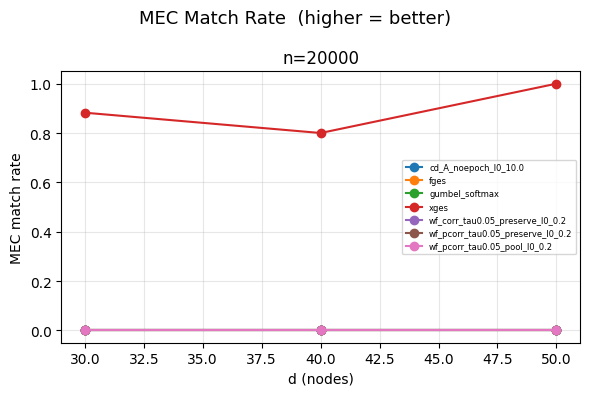

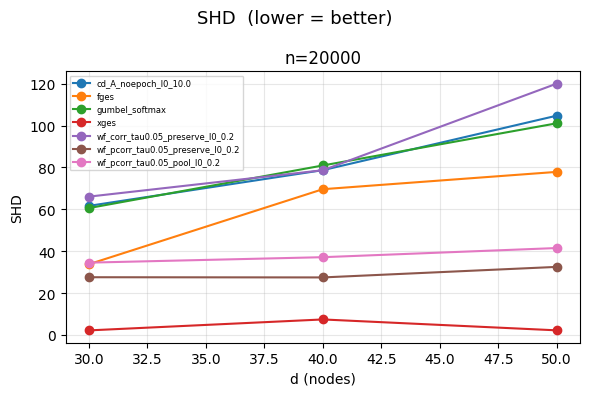

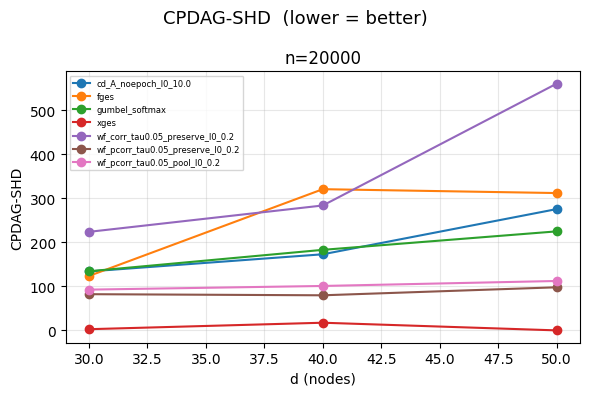

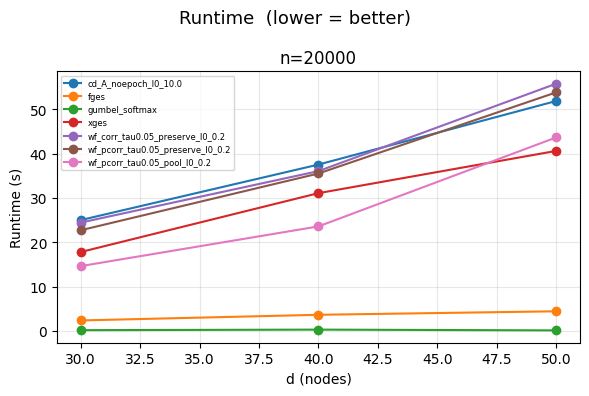

In [55]:
# 12) 可视化：MEC match rate / SHD / CPDAG-SHD / runtime（按 n_samples 分面）
# ──────────────────────────────────────────────────────────────────────────────

if 'df_all_trials' not in dir() or len(df_all_trials) == 0:
    print('请先运行 Cell 10。')
else:
    _n_vals = sorted(df_all_trials['n_samples'].unique())
    _algs   = [a for a in ALGORITHM_ORDER if a in df_all_trials['algorithm'].unique()]

    for _metric, _ylabel, _title in [
        ('mec_match',   'MEC match rate', 'MEC Match Rate  (higher = better)'),
        ('shd',         'SHD',            'SHD  (lower = better)'),
        ('cpdag_shd',   'CPDAG-SHD',      'CPDAG-SHD  (lower = better)'),
        ('runtime_sec', 'Runtime (s)',    'Runtime  (lower = better)'),
    ]:
        fig, axes = plt.subplots(1, len(_n_vals), figsize=(6 * len(_n_vals), 4),
                                 sharey=True, squeeze=False)
        for _ci, _n in enumerate(_n_vals):
            ax   = axes[0][_ci]
            _sub = df_all_trials[df_all_trials['n_samples'] == _n]
            _agg = _sub.groupby(['d', 'algorithm'])[_metric].mean().reset_index()
            for _a in _algs:
                _vals = _agg[_agg['algorithm'] == _a]
                ax.plot(_vals['d'], _vals[_metric], marker='o', label=_a)
            ax.set_title(f'n={_n}')
            ax.set_xlabel('d (nodes)')
            if _ci == 0:
                ax.set_ylabel(_ylabel)
            ax.legend(fontsize=6, loc='best')
            ax.grid(True, alpha=0.3)
        fig.suptitle(_title, fontsize=13)
        plt.tight_layout()
        plt.show()


===== SHD 最大值（行=(d, n), 列=algorithm）=====


,algorithm,cd_A_noepoch_l0_2.0,cd_A_noepoch_l0_5.0,cd_A_noepoch_l0_10.0,fges,gumbel_softmax,xges
d,n_samples,,,,,,
30,20000,92,81,82,10,42,4
40,20000,111,100,92,185,90,26
50,20000,209,189,178,212,114,5


===== CPDAG-SHD 最大值（行=(d, n), 列=algorithm）=====


,algorithm,cd_A_noepoch_l0_2.0,cd_A_noepoch_l0_5.0,cd_A_noepoch_l0_10.0,fges,gumbel_softmax,xges
d,n_samples,,,,,,
30,20000,256,195,199,5,58,0
40,20000,345,273,213,805,215,99
50,20000,1788,1373,1083,843,281,0



===== 明细（含 mean / max / trials）=====


,algorithm,d,n_samples,shd_max,shd_mean,cpdag_shd_max,cpdag_shd_mean,trials
0,cd_A_noepoch_l0_2.0,30,20000,92,63.50,256,153.15,20
1,cd_A_noepoch_l0_2.0,40,20000,111,79.05,345,200.35,20
2,cd_A_noepoch_l0_2.0,50,20000,209,114.20,1788,405.00,20
3,cd_A_noepoch_l0_5.0,30,20000,81,61.75,195,135.75,20
4,cd_A_noepoch_l0_5.0,40,20000,100,79.80,273,182.75,20
5,cd_A_noepoch_l0_5.0,50,20000,189,107.85,1373,313.25,20
6,cd_A_noepoch_l0_10.0,30,20000,82,61.65,199,133.85,20
7,cd_A_noepoch_l0_10.0,40,20000,92,78.70,213,172.80,20
8,cd_A_noepoch_l0_10.0,50,20000,178,104.70,1083,275.35,20
9,fges,30,20000,10,10.00,5,5.00,1


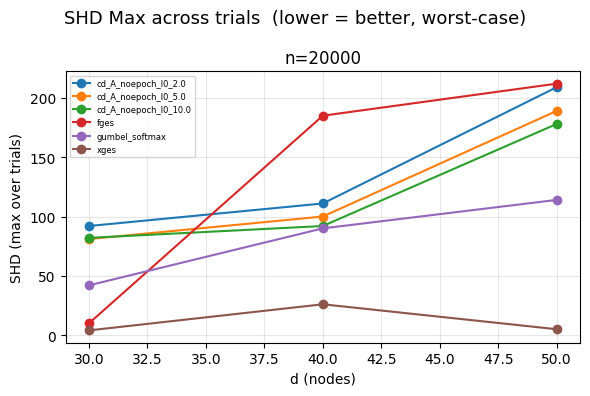

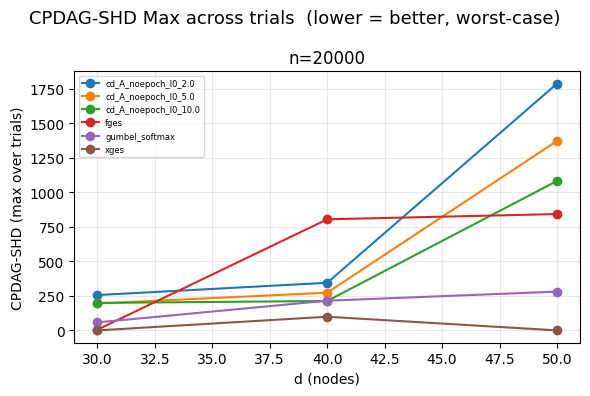

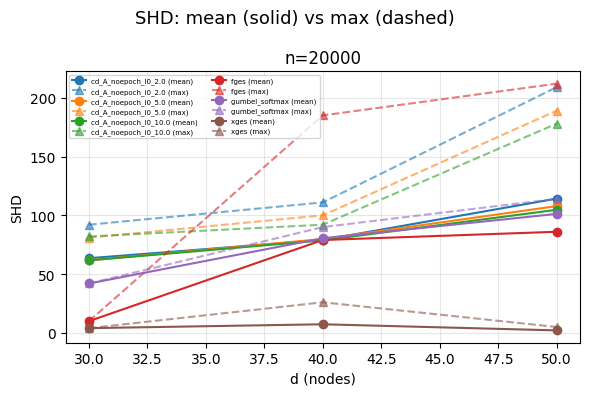

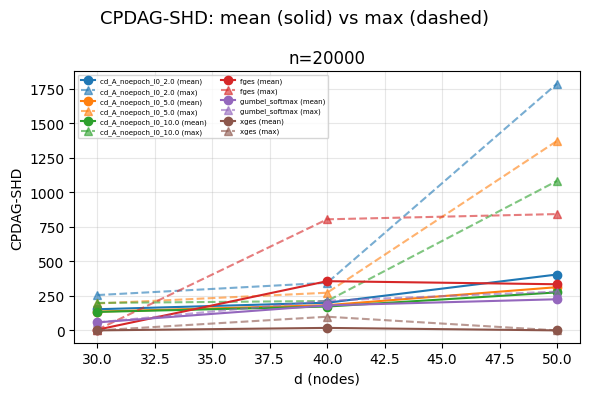

In [15]:
# 12b) 每个 (d, n) 设定下 SHD / CPDAG-SHD 最大值对比
# ──────────────────────────────────────────────────────────────────────────────
# 对每个 (d, n, algorithm) 取该设定下所有 trial 的 SHD / CPDAG-SHD 最大值

if 'df_all_trials' not in dir() or len(df_all_trials) == 0:
    print('请先运行 Cell 10。')
else:
    _algs_present = [a for a in ALGORITHM_ORDER
                     if a in df_all_trials['algorithm'].unique()]

    def _plot_max_metric(_metric: str, _ylabel: str, _title: str):
        _n_vals = sorted(df_all_trials['n_samples'].unique())
        fig, axes = plt.subplots(1, len(_n_vals), figsize=(6 * len(_n_vals), 4),
                                 sharey=True, squeeze=False)
        for _ci, _n in enumerate(_n_vals):
            ax   = axes[0][_ci]
            _sub = df_all_trials[df_all_trials['n_samples'] == _n]
            _agg = _sub.groupby(['d', 'algorithm'])[_metric].max().reset_index()
            for _a in _algs_present:
                _vals = _agg[_agg['algorithm'] == _a]
                ax.plot(_vals['d'], _vals[_metric], marker='o', label=_a)
            ax.set_title(f'n={_n}')
            ax.set_xlabel('d (nodes)')
            if _ci == 0:
                ax.set_ylabel(_ylabel)
            ax.legend(fontsize=6, loc='best')
            ax.grid(True, alpha=0.3)
        fig.suptitle(_title, fontsize=13)
        plt.tight_layout()
        plt.show()

    def _plot_mean_vs_max(_metric: str, _ylabel: str, _title: str):
        _n_vals = sorted(df_all_trials['n_samples'].unique())
        fig, axes = plt.subplots(1, len(_n_vals), figsize=(6 * len(_n_vals), 4),
                                 sharey=True, squeeze=False)
        for _ci, _n in enumerate(_n_vals):
            ax   = axes[0][_ci]
            _sub = df_all_trials[df_all_trials['n_samples'] == _n]
            _agg_mean = _sub.groupby(['d', 'algorithm'])[_metric].mean().reset_index()
            _agg_max  = _sub.groupby(['d', 'algorithm'])[_metric].max().reset_index()
            _cmap = plt.get_cmap('tab10')
            for _i, _a in enumerate(_algs_present):
                _c = _cmap(_i % 10)
                _m = _agg_mean[_agg_mean['algorithm'] == _a]
                _x = _agg_max[_agg_max['algorithm']  == _a]
                ax.plot(_m['d'], _m[_metric], marker='o', linestyle='-',  color=_c,
                        label=f'{_a} (mean)')
                ax.plot(_x['d'], _x[_metric], marker='^', linestyle='--', color=_c,
                        label=f'{_a} (max)', alpha=0.6)
            ax.set_title(f'n={_n}')
            ax.set_xlabel('d (nodes)')
            if _ci == 0:
                ax.set_ylabel(_ylabel)
            ax.legend(fontsize=5, loc='best', ncol=2)
            ax.grid(True, alpha=0.3)
        fig.suptitle(_title, fontsize=13)
        plt.tight_layout()
        plt.show()

    # --- 汇总表 ---
    df_summary_max = (
        df_all_trials
        .groupby(['algorithm', 'd', 'n_samples'], as_index=False)
        .agg(shd_max        = ('shd',       'max'),
             shd_mean       = ('shd',       'mean'),
             cpdag_shd_max  = ('cpdag_shd', 'max'),
             cpdag_shd_mean = ('cpdag_shd', 'mean'),
             trials         = ('trial_id',  'count'))
    )

    _order_map = {a: i for i, a in enumerate(_algs_present)}
    df_summary_max['_ord'] = df_summary_max['algorithm'].map(_order_map).fillna(999)
    df_summary_max = (
        df_summary_max.sort_values(['_ord', 'd', 'n_samples'])
        .drop(columns='_ord').reset_index(drop=True)
    )

    for _col, _title in [('shd_max',       '===== SHD 最大值（行=(d, n), 列=algorithm）====='),
                         ('cpdag_shd_max', '===== CPDAG-SHD 最大值（行=(d, n), 列=algorithm）=====')]:
        _pivot = (df_summary_max
                  .pivot_table(index=['d', 'n_samples'], columns='algorithm',
                               values=_col, aggfunc='max')
                  .reindex(columns=_algs_present))
        print(_title)
        display(_pivot.style.format('{:.0f}'))

    print('\n===== 明细（含 mean / max / trials）=====')
    display(
        df_summary_max.style.format({
            'shd_max':        '{:.0f}',
            'shd_mean':       '{:.2f}',
            'cpdag_shd_max':  '{:.0f}',
            'cpdag_shd_mean': '{:.2f}',
        })
    )

    _plot_max_metric('shd',       'SHD (max over trials)',
                     'SHD Max across trials  (lower = better, worst-case)')
    _plot_max_metric('cpdag_shd', 'CPDAG-SHD (max over trials)',
                     'CPDAG-SHD Max across trials  (lower = better, worst-case)')

    _plot_mean_vs_max('shd',       'SHD',
                      'SHD: mean (solid) vs max (dashed)')
    _plot_mean_vs_max('cpdag_shd', 'CPDAG-SHD',
                      'CPDAG-SHD: mean (solid) vs max (dashed)')


In [ ]:
# 13) 跳过记录分析
# ──────────────────────────────────────────────────────────────────────────────

if _SKIP_LOGS:
    df_skips = pd.DataFrame(_SKIP_LOGS)
    print(f'Total skips: {len(df_skips)}')
    display(df_skips.groupby('algorithm')['reason'].value_counts().rename('count').reset_index())
else:
    print('No skips -- 所有算法在全部 trial 上均成功运行。')


No skips -- 所有算法在全部 trial 上均成功运行。
